In [17]:
#. Imports and Data Loading
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"D:\prepare\network_security_data.csv")

In [3]:
#Basic preprocessing
df.drop(columns=["connection_id"], inplace=True)

In [4]:
target = "threat_detected"

In [5]:
df_encoded = pd.get_dummies(
    df,
    columns=["connection_type"],
    drop_first=True
)

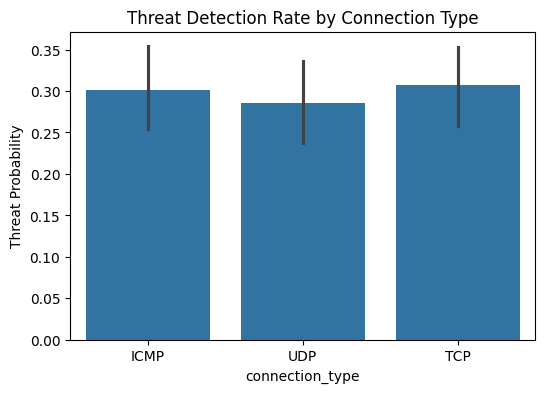

In [6]:
#Threat rate by connection type
plt.figure(figsize=(6,4))
sns.barplot(
    x="connection_type",
    y="threat_detected",
    data=df,
    estimator=np.mean
)
plt.title("Threat Detection Rate by Connection Type")
plt.ylabel("Threat Probability")
plt.show()

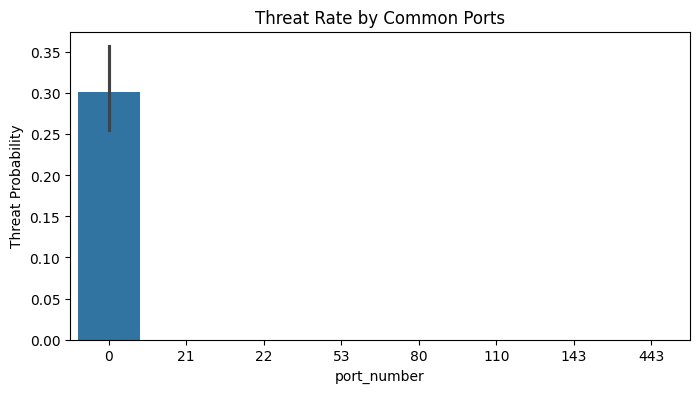

In [7]:
#Threat rate by port number
top_ports = df["port_number"].value_counts().head(8).index
port_subset = df[df["port_number"].isin(top_ports)]

plt.figure(figsize=(8,4))
sns.barplot(
    x="port_number",
    y="threat_detected",
    data=port_subset,
    estimator=np.mean
)
plt.title("Threat Rate by Common Ports")
plt.ylabel("Threat Probability")
plt.show()

C:\Users\Sandesh Khatiwada\AppData\Local\Temp\ipykernel_9036\1205621950.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  packet_group = df.groupby(


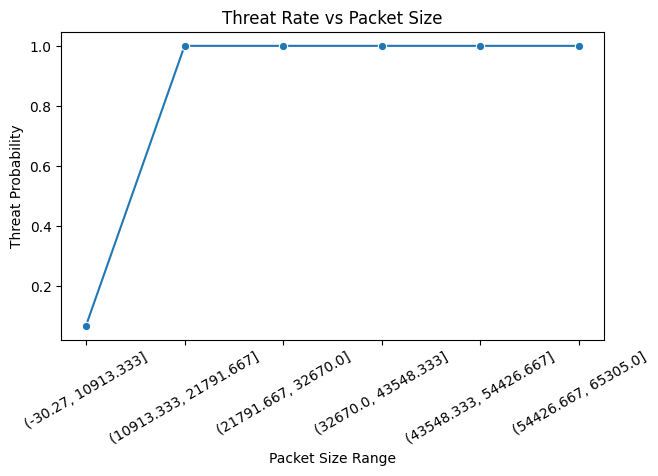

In [8]:
#Packet size vs threat
packet_group = df.groupby(
    pd.cut(df["packet_size"], bins=6)
)["threat_detected"].mean()

plt.figure(figsize=(7,4))
sns.lineplot(
    x=packet_group.index.astype(str),
    y=packet_group.values,
    marker="o"
)
plt.title("Threat Rate vs Packet Size")
plt.xlabel("Packet Size Range")
plt.ylabel("Threat Probability")
plt.xticks(rotation=30)
plt.show()

C:\Users\Sandesh Khatiwada\AppData\Local\Temp\ipykernel_9036\4148305856.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_group = df.groupby(


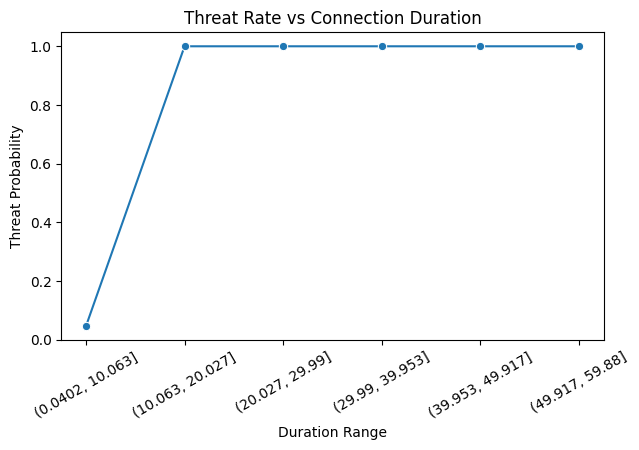

In [9]:
#Duration vs threat
duration_group = df.groupby(
    pd.cut(df["duration"], bins=6)
)["threat_detected"].mean()

plt.figure(figsize=(7,4))
sns.lineplot(
    x=duration_group.index.astype(str),
    y=duration_group.values,
    marker="o"
)
plt.title("Threat Rate vs Connection Duration")
plt.xlabel("Duration Range")
plt.ylabel("Threat Probability")
plt.xticks(rotation=30)
plt.show()

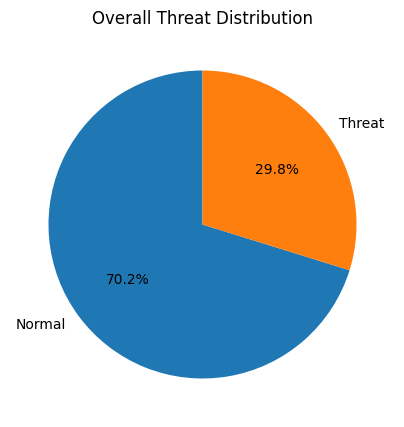

In [10]:
#overall threat distribution
threat_counts = df["threat_detected"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    threat_counts,
    labels=["Normal", "Threat"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Overall Threat Distribution")
plt.show()

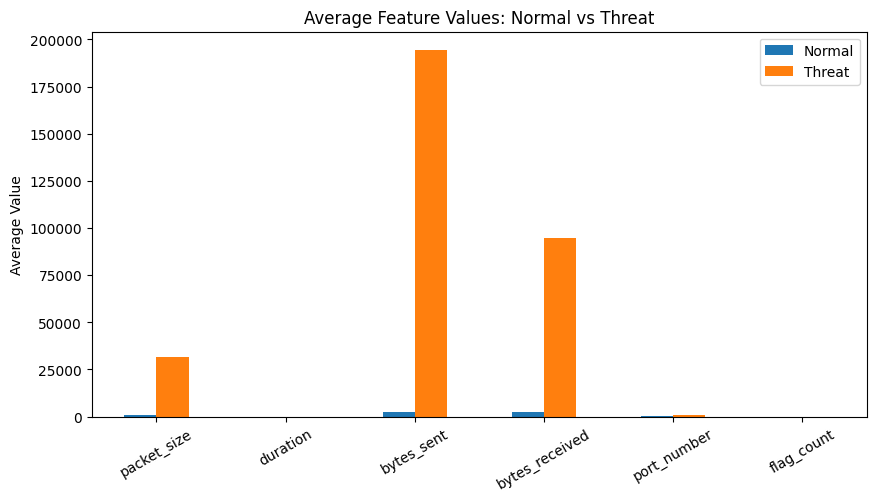

In [11]:
#Combined feature comparison
combined_means = df.groupby("threat_detected").mean(numeric_only=True)

combined_means.T.plot(kind="bar", figsize=(10,5))
plt.title("Average Feature Values: Normal vs Threat")
plt.ylabel("Average Value")
plt.xticks(rotation=30)
plt.legend(["Normal", "Threat"])
plt.show()

In [12]:
#Train-Test Split
X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [13]:
#Feature Scaling
numeric_features = [
    "packet_size",
    "duration",
    "bytes_sent",
    "bytes_received",
    "port_number",
    "flag_count"
]

scaler = StandardScaler()

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [22]:
#Model Training (LinearRegression)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
#prediction
y_pred_continuous = model.predict(X_test)

# Convert to binary using threshold
y_pred = (y_pred_continuous >= 0.5).astype(int)

In [24]:
#Evaluation
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       176
           1       1.00      0.96      0.98        74

    accuracy                           0.99       250
   macro avg       0.99      0.98      0.99       250
weighted avg       0.99      0.99      0.99       250

Confusion Matrix:

[[176   0]
 [  3  71]]


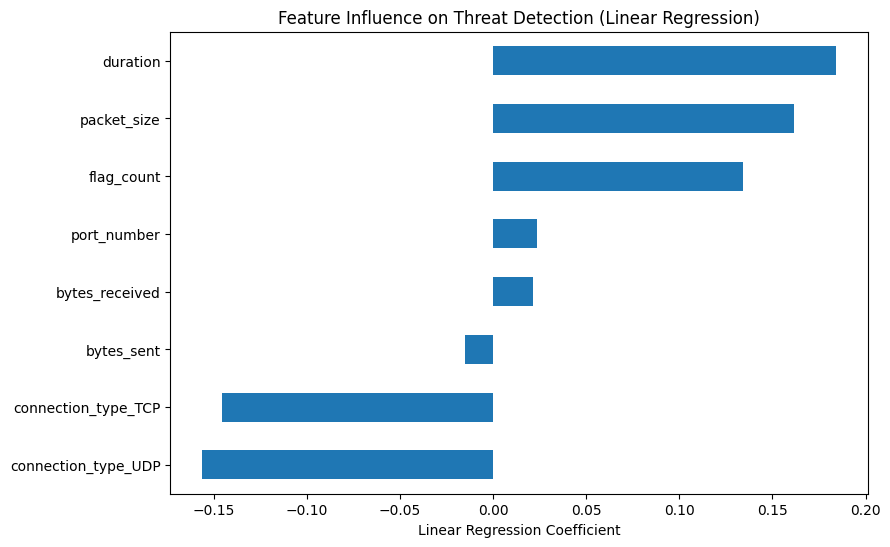

In [25]:
#Feature Importance
importance = pd.Series(
    model.coef_,
    index=X_train.columns
).sort_values()

importance.plot(kind="barh", figsize=(9,6))
plt.title("Feature Influence on Threat Detection (Linear Regression)")
plt.xlabel("Linear Regression Coefficient")
plt.show()